<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\2644734827.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 0| Loss = 10.009809494018555| Lnorm=0.9999585151672363| norm=2.0749448594870046e-05
Epoch 500| Loss = 0.0005442978581413627| Lnorm=6.074492944208032e-07| norm=1.000779390335083
Epoch 1000| Loss = 0.00029231252847239375| Lnorm=4.0395718770014355e-08| norm=1.0002009868621826
Epoch 1500| Loss = 2.1957765056868084e-05| Lnorm=5.902398925172747e-08| norm=0.9997570514678955
Epoch 2000| Loss = 4.025801536045037e-05| Lnorm=1.3489740524619265e-07| norm=1.000367283821106
Epoch 2500| Loss = 5.8037854614667594e-05| Lnorm=1.8407037316592323e-07| norm=1.0004290342330933
Epoch 3000| Loss = 0.0010352693498134613| Lnorm=2.0538732314889785e-06| norm=1.0014331340789795
Epoch 3500| Loss = 2.8784120331692975e-06| Lnorm=1.2960867934452835e-09| norm=1.0000360012054443
Epoch 4000| Loss = 7.759495201753452e-05| Lnorm=1.1852625902974978e-07| norm=1.0003442764282227
Epoch 4500| Loss = 3.611204738263041e-05| Lnorm=8.356870750958478e-08| norm=1.0002890825271606
8.528391481377184e-05
0.02548152208328247


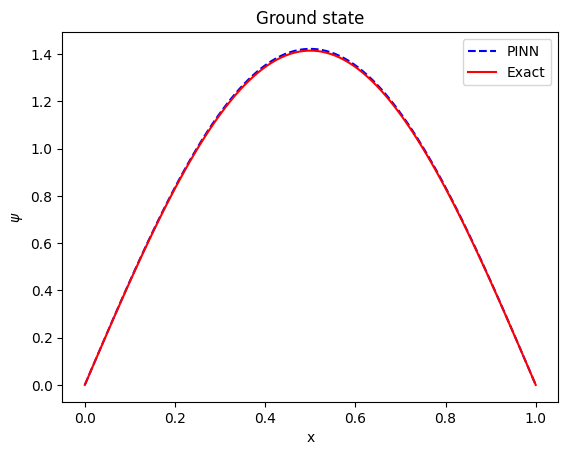

PDE Loss      : 0.00012796309601981193
Max Residual  : 0.03190755844116211
Norm          : 1.0004608631134033


In [70]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =pde_loss + 10*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='blue',linestyle='--')
plt.plot(x_np,psi_exact,label='Exact',color='red')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('Ground state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())

<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\2419765230.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 0| Loss = 300008.75| Lnorm=0.9992159008979797| norm=0.0003921391034964472
Epoch 500| Loss = 168358.671875| Lnorm=0.14021393656730652| norm=0.6255484819412231
Epoch 1000| Loss = 156217.828125| Lnorm=0.0957329124212265| norm=0.6905926465988159
Epoch 1500| Loss = 66860.9609375| Lnorm=0.03870398923754692| norm=0.803266704082489
Epoch 2000| Loss = 14517.0712890625| Lnorm=0.007733104284852743| norm=0.9120619297027588
Epoch 2500| Loss = 1582.9857177734375| Lnorm=0.00016650061297696084| norm=0.9870964884757996
Epoch 3000| Loss = 1170.922607421875| Lnorm=4.6360901251318865e-06| norm=0.9978468418121338
Epoch 3500| Loss = 1120.2381591796875| Lnorm=7.074840596033027e-06| norm=0.9973401427268982
Epoch 4000| Loss = 3.3137121200561523| Lnorm=5.726562903873855e-07| norm=0.9992432594299316
Epoch 4500| Loss = 3.9062044620513916| Lnorm=1.315471251928102e-07| norm=0.9996373057365417
0.3207661509513855
1.793844223022461


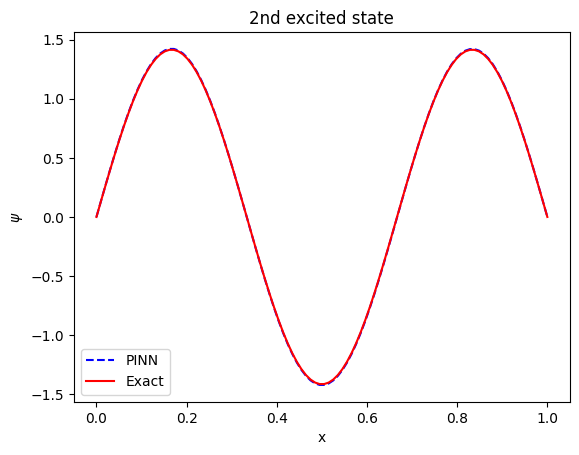

PDE Loss      : 0.31814074516296387
Max Residual  : 1.8011703491210938
Norm          : 1.0000375509262085


In [74]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=9*torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =100*pde_loss + 300000*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(3*np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='blue',linestyle='--')
plt.plot(x_np,psi_exact,label='Exact',color='red')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('2nd excited state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())


Epoch 0| Loss = 20004.87890625| Lnorm=0.9997966289520264| norm=0.00010170904715778306


<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\313292885.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 500| Loss = 2664.568359375| Lnorm=0.004459731746464968| norm=0.933218777179718
Epoch 1000| Loss = 1631.13623046875| Lnorm=0.001724514295347035| norm=0.958472728729248
Epoch 1500| Loss = 1593.45654296875| Lnorm=0.0016581803793087602| norm=0.9592792391777039
Epoch 2000| Loss = 1579.6654052734375| Lnorm=0.0016285571036860347| norm=0.959644615650177
Epoch 2500| Loss = 1572.637451171875| Lnorm=0.0016141902888193727| norm=0.9598230123519897
Epoch 3000| Loss = 1567.5455322265625| Lnorm=0.0016014707507565618| norm=0.9599816203117371
Epoch 3500| Loss = 1601.6124267578125| Lnorm=0.0015111902030184865| norm=0.9611259698867798
Epoch 4000| Loss = 1565.0775146484375| Lnorm=0.0015883025480434299| norm=0.9601464867591858
Epoch 4500| Loss = 1565.174560546875| Lnorm=0.0016256286762654781| norm=0.9596809148788452
15.315308570861816
18.326351165771484


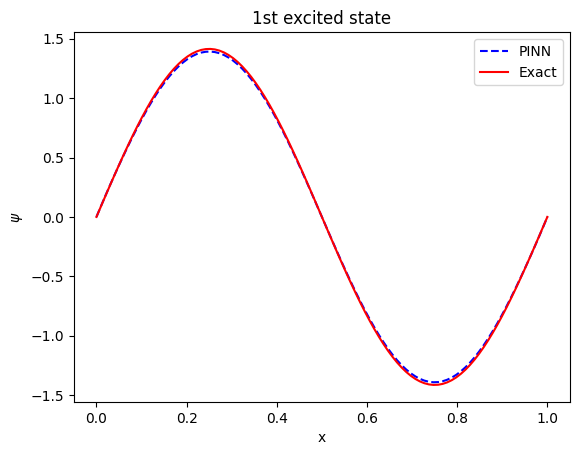

PDE Loss      : 15.315157890319824
Max Residual  : 18.326351165771484
Norm          : 0.9601166248321533


In [72]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=4*torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =100*pde_loss + 20000*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(2*np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='blue',linestyle='--')
plt.plot(x_np,psi_exact,label='Exact',color='red')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('1st excited state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())
